极端洪水事件分析 (3种台风距离场景)

正在加载模型预测数据...
✓ 成功加载 6 个模型

正在加载辅助数据...
✓ 成功加载辅助数据: 10592 条记录

正在识别3种不同距离的台风洪水事件...

识别到 105 个完整洪水事件

近距离台风事件: 2008-06-28, 峰值=4340 m³/s, 距离=35 km
中距离台风事件: 2006-07-17, 峰值=7670 m³/s, 距离=327 km
远距离台风事件: 2007-08-23, 峰值=2840 m³/s, 距离=445 km

===== 所有事件-模型峰值汇总 =====

事件1：观测峰值 4340 m³/s（2008-06-28）
  ANN        预测峰值：4257 m³/s（2008-06-29）
  LR         预测峰值：4202 m³/s（2008-06-29）
  RF         预测峰值：3227 m³/s（2008-06-29）
  XGB        预测峰值：3948 m³/s（2008-06-29）
  ANN-EnTY   预测峰值：4616 m³/s（2008-06-29）
  LR-EnTY    预测峰值：4443 m³/s（2008-06-29）

事件2：观测峰值 7670 m³/s（2006-07-17）
  ANN        预测峰值：6579 m³/s（2006-07-17）
  LR         预测峰值：6349 m³/s（2006-07-17）
  RF         预测峰值：4836 m³/s（2006-07-17）
  XGB        预测峰值：6114 m³/s（2006-07-17）
  ANN-EnTY   预测峰值：6890 m³/s（2006-07-17）
  LR-EnTY    预测峰值：6243 m³/s（2006-07-17）

事件3：观测峰值 2840 m³/s（2007-08-23）
  ANN        预测峰值：2882 m³/s（2007-08-23）
  LR         预测峰值：2948 m³/s（2007-08-23）
  RF         预测峰值：2621 m³/s（2007-08-24）
  XGB        预测峰值：2955

C:\Users\Administrator\AppData\Local\Temp\ipykernel_22848\1809570055.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



✓ 图表已保存至: results_v3/Figure_distance_scenarios.png


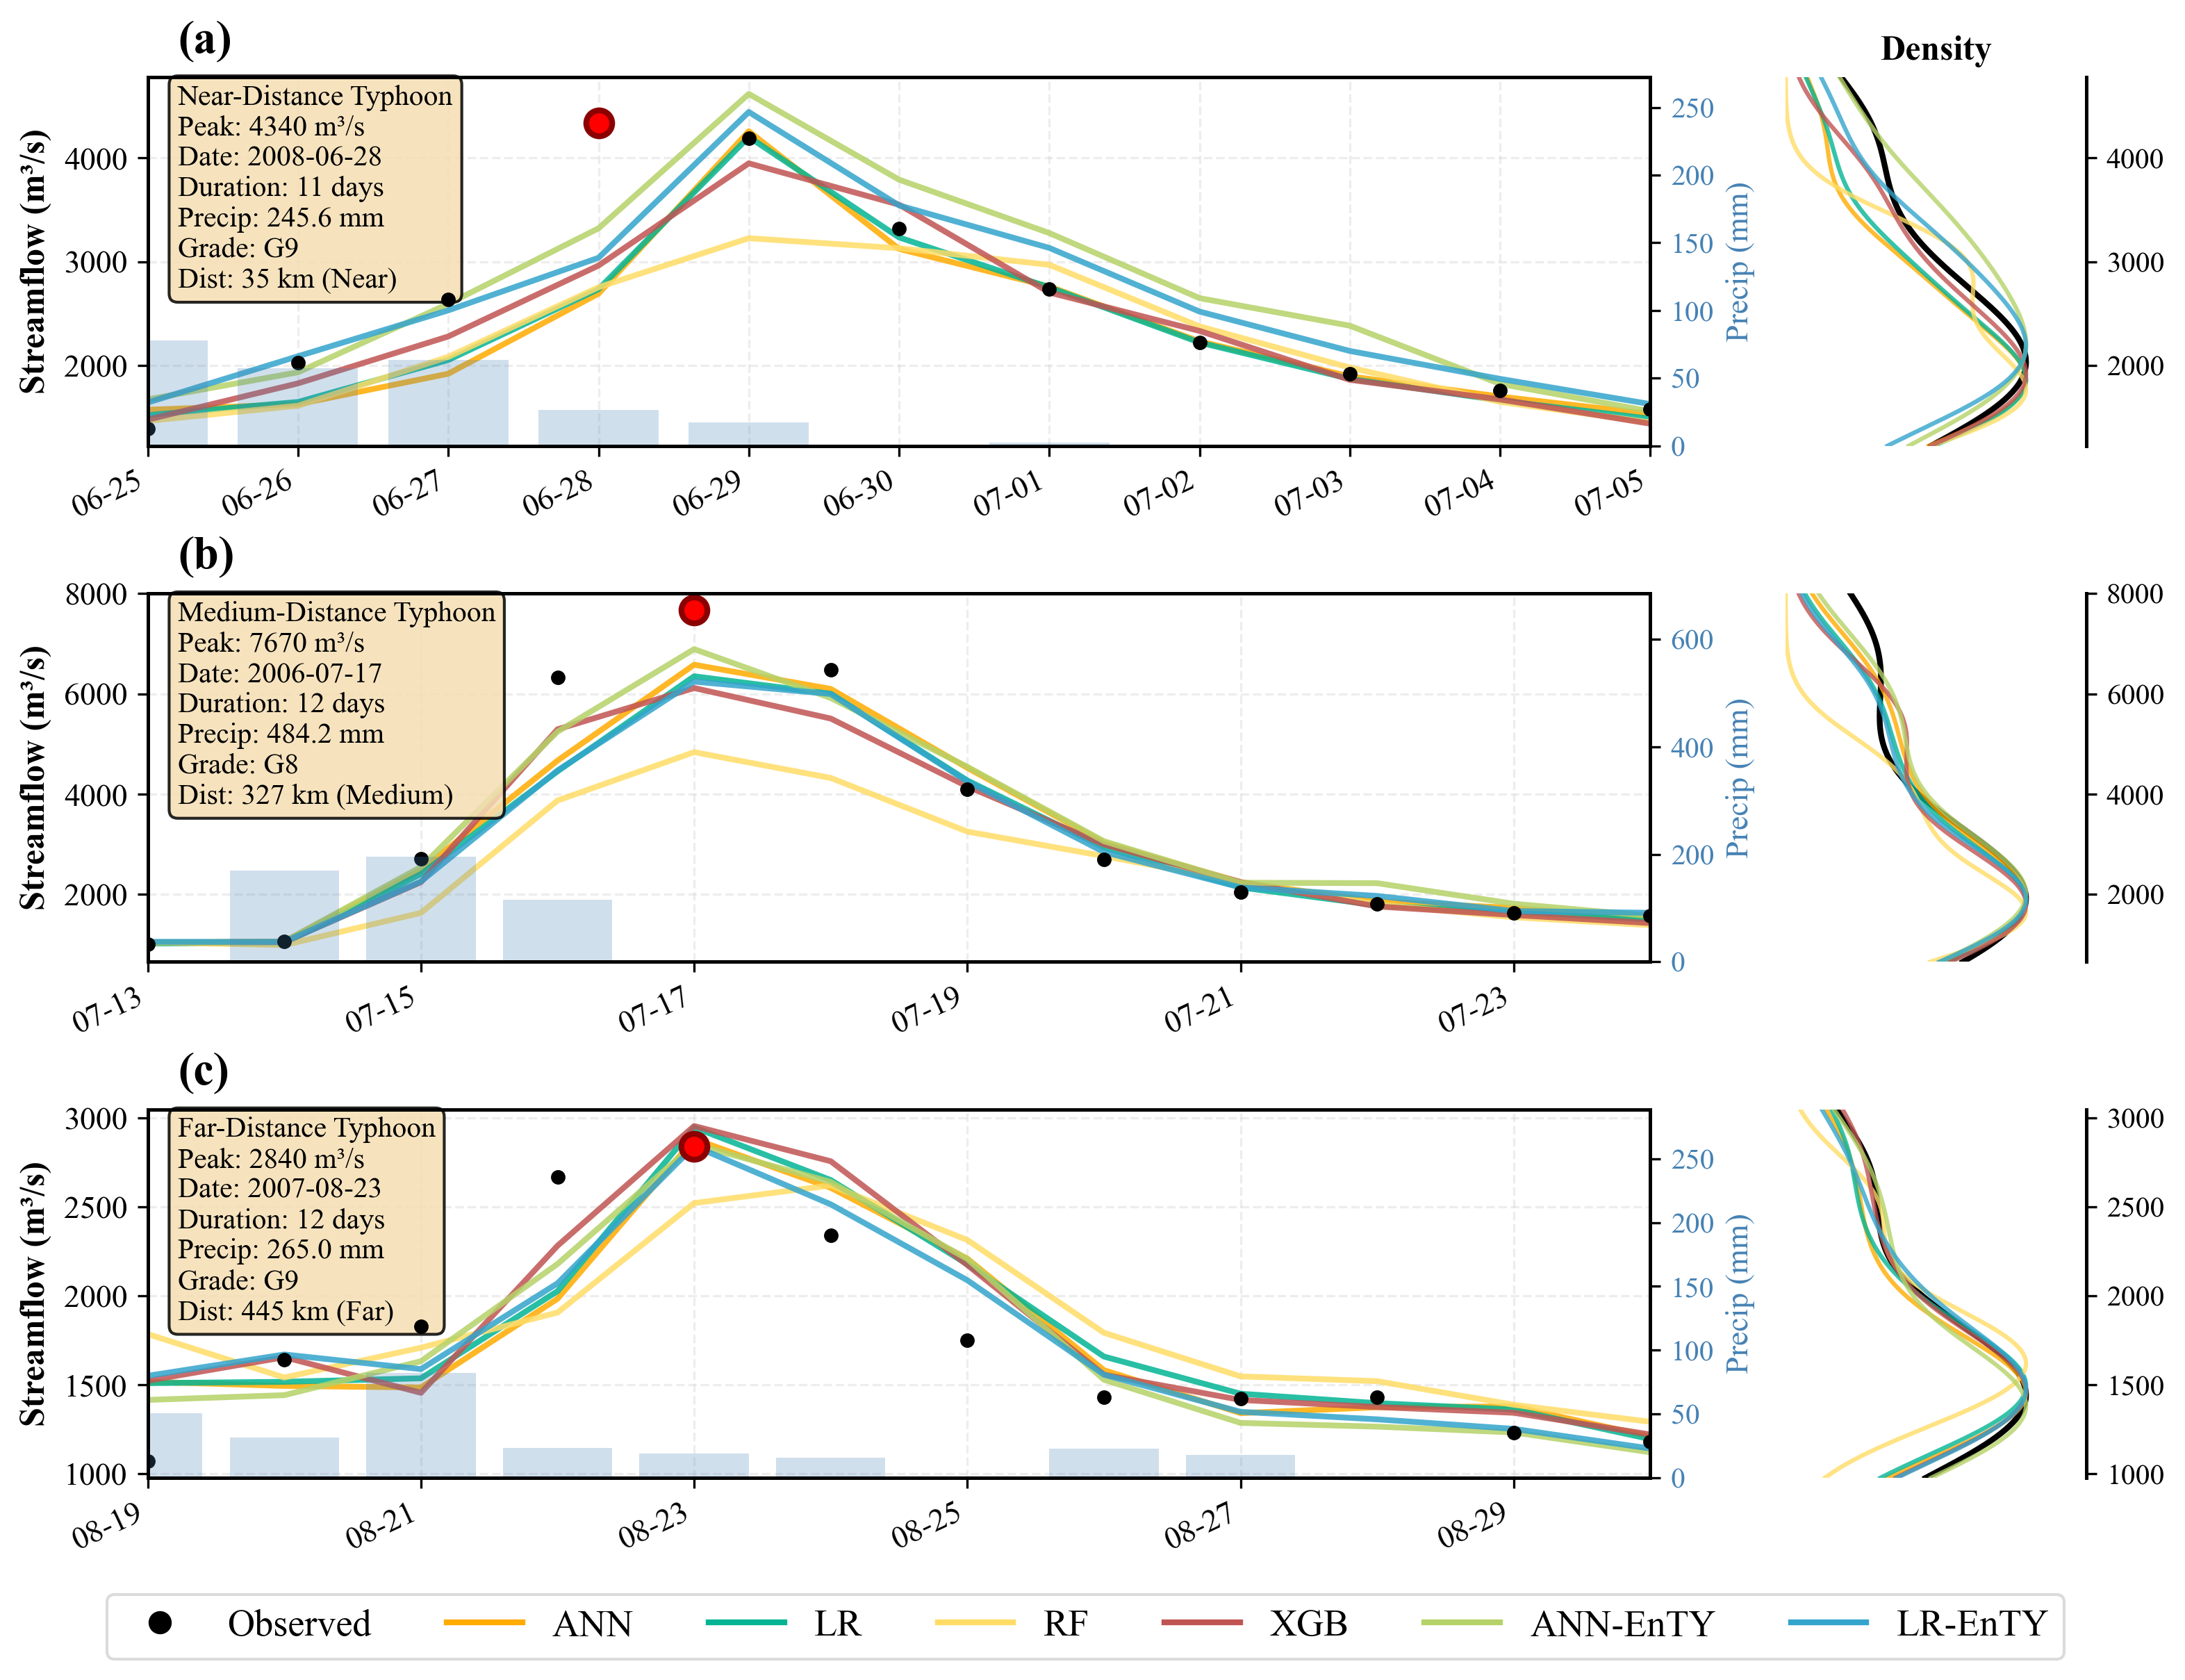


✓ 分析完成!


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from datetime import datetime, timedelta
from matplotlib.dates import AutoDateLocator, DateFormatter
from scipy.stats import gaussian_kde

# -------------------------- 基础配置 --------------------------
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 13
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["lines.linewidth"] = 2.0

MODEL_STYLE = {
    "color": {
        "Observed": "black",
        "LR": "#02b494",
        "ANN": "#ffab00",
        "RF": "#ffdc66",
        "XGB": "#c05452",
        "LR-EnTY": "#33a4cc",
        "ANN-EnTY": "#b5d268"
    }
}

# -------------------------- 数据加载 --------------------------
def load_auxiliary_data(data_file='../数据/typhoon_daily_boluo.csv'):
    try:
        aux_df = pd.read_csv(data_file)
        aux_df['date'] = pd.to_datetime(aux_df['date'])
        aux_columns = ['date', '博罗', '台风等级', '台风强度', '风速', '距离博罗站', '气压']
        available_cols = [col for col in aux_columns if col in aux_df.columns]
        return aux_df[available_cols]
    except Exception as e:
        print(f"加载辅助数据失败: {e}")
        return None

def load_predictions(pred_dir='predictions_v2'):
    model_mapping = {
        'baseline_ANN': 'ANN',
        'baseline_LR': 'LR',
        'baseline_RF': 'RF',
        'baseline_XGB': 'XGB',
        'flood_focused_ann': 'ANN-EnTY',
        'with_typhoon_enhanced_LR': 'LR-EnTY'
    }
    predictions = {}
    
    for filename in os.listdir(pred_dir):
        if filename.endswith('_predictions.csv'):
            model_name = filename.replace('_predictions.csv', '')
            if model_name not in model_mapping:
                continue
            file_path = os.path.join(pred_dir, filename)
            try:
                pred_df = pd.read_csv(file_path)
                pred_df['date'] = pd.to_datetime(pred_df['date'])
                predictions[model_mapping[model_name]] = pred_df
            except:
                continue
    return predictions

# -------------------------- 完整洪水事件识别 --------------------------
def identify_complete_flood_events(observed_data, aux_data):
    """
    识别完整的洪水事件（从起涨到退水）
    """
    obs = observed_data.copy()
    obs['date'] = pd.to_datetime(obs['date'])
    obs = obs.sort_values('date').reset_index(drop=True)
    
    # 合并台风数据
    merged = obs.merge(aux_data, on='date', how='left')
    
    # 计算流量变化
    merged['flow_diff'] = merged['observed'].diff()
    merged['flow_pct_change'] = merged['observed'].pct_change()
    
    # 识别局部峰值（洪峰）
    merged['is_peak'] = (
        (merged['observed'] > merged['observed'].shift(1)) & 
        (merged['observed'] > merged['observed'].shift(-1)) &
        (merged['observed'] > merged['observed'].quantile(0.85))  # 只考虑较大洪水
    )
    
    # 找到所有洪峰
    peaks = merged[merged['is_peak']].copy()
    
    # 为每个洪峰识别完整事件窗口
    events = []
    for idx, peak in peaks.iterrows():
        # 向前找起涨点（流量开始显著上升）
        # 向前找起涨点（流量开始显著上升），最多5天
        start_idx = idx
        
        for i in range(idx - 1, max(0, idx - 10), -1):
            if i == 0:
                start_idx = 0
                break
            # 计算斜率（流量变化率）
            slope = merged.loc[i, 'observed'] - merged.loc[i-1, 'observed']
            if slope < 0.2:
                start_idx = i
                break
        else:
            # 如果没找到，就固定为峰值前10天
            start_idx = max(0, idx - 10)
        
        # 向后找退水点（斜率绝对值小于0.3），最多7天
        end_idx = idx
        for i in range(idx + 1, min(len(merged), idx + 7)):
            if i == len(merged) - 1:
                end_idx = len(merged) - 1
                break
            # 计算斜率（流量变化率）
            slope = merged.loc[i+1, 'observed'] - merged.loc[i, 'observed']
            if abs(slope) < 0.3:  # 退水时斜率为负，用绝对值
                end_idx = i
                break
        else:
            # 如果没找到，就固定为峰值后7天
            end_idx = min(len(merged) - 1, idx + 7)
        
        # 提取事件数据
        event_data = merged.iloc[start_idx:end_idx+1].copy()
        
        # 计算事件的台风特征
        event_aux = aux_data[
            (aux_data['date'] >= event_data['date'].min()) & 
            (aux_data['date'] <= event_data['date'].max())
        ]
        
        event_info = {
            'data': event_data,
            'start_date': event_data['date'].min(),
            'end_date': event_data['date'].max(),
            'peak_date': peak['date'],
            'peak_value': peak['observed'],
            'peak_idx': idx,
            'duration': len(event_data),
        }
        
        # 分析台风特征
        event_info['characteristics'] = analyze_event_characteristics(
            event_data, event_aux
        )
        
        events.append(event_info)
    
    return events

def find_three_distance_scenarios(observed_data, aux_data):
    """
    按照台风距离分类选择3个洪峰最大的事件:
    1. 近距离台风 (0-150 km)
    2. 中距离台风 (150-350 km)
    3. 远距离台风 (>350 km)
    """
    # 识别所有完整洪水事件
    all_events = identify_complete_flood_events(observed_data, aux_data)
    
    # 按峰值流量排序
    all_events.sort(key=lambda x: x['peak_value'], reverse=True)
    
    print(f"\n识别到 {len(all_events)} 个完整洪水事件")
    
    # 分类距离区间
    near_events = []   # 0-150 km
    mid_events = []    # 150-350 km
    far_events = []    # >350 km
    
    for event in all_events:
        char = event['characteristics']
        
        # 跳过无台风影响的事件
        if char.get('typhoon_days', 0) == 0:
            continue
        
        min_dist = char.get('min_typhoon_distance', 999999)
        
        if min_dist <= 150:
            near_events.append(event)
        elif min_dist <= 350:
            mid_events.append(event)
        else:
            far_events.append(event)
    
    # 选择每个类别中峰值最大的事件
    selected = []
    
    if near_events:
        event = near_events[0]
        event['characteristics']['type'] = 'Near-Distance Typhoon'
        event['characteristics']['distance_category'] = f"{event['characteristics']['min_typhoon_distance']:.0f} km (Near)"
        selected.append(event)
        print(f"\n近距离台风事件: {event['peak_date'].strftime('%Y-%m-%d')}, 峰值={event['peak_value']:.0f} m³/s, 距离={event['characteristics']['min_typhoon_distance']:.0f} km")
    
    if mid_events:
        event = mid_events[0]
        event['characteristics']['type'] = 'Medium-Distance Typhoon'
        event['characteristics']['distance_category'] = f"{event['characteristics']['min_typhoon_distance']:.0f} km (Medium)"
        selected.append(event)
        print(f"中距离台风事件: {event['peak_date'].strftime('%Y-%m-%d')}, 峰值={event['peak_value']:.0f} m³/s, 距离={event['characteristics']['min_typhoon_distance']:.0f} km")
    
    if far_events:
        event = far_events[1]
        event['characteristics']['type'] = 'Far-Distance Typhoon'
        event['characteristics']['distance_category'] = f"{event['characteristics']['min_typhoon_distance']:.0f} km (Far)"
        selected.append(event)
        print(f"远距离台风事件: {event['peak_date'].strftime('%Y-%m-%d')}, 峰值={event['peak_value']:.0f} m³/s, 距离={event['characteristics']['min_typhoon_distance']:.0f} km")
    
    # 如果某类没找到，用剩余最大的事件补充
    if len(selected) < 3:
        print(f"\n警告: 仅找到 {len(selected)} 个距离类别事件，用剩余最大洪水补充")
        remaining = [e for e in all_events if e not in selected and e['characteristics'].get('typhoon_days', 0) > 0]
        for event in remaining:
            if len(selected) >= 3:
                break
            event['characteristics']['type'] = f'Typhoon Event {len(selected)+1}'
            selected.append(event)
    
    return selected[:3]

def analyze_event_characteristics(event_data, aux_data):
    """分析洪水事件特征"""
    char = {
        'peak_flow': event_data['observed'].max(),
        'mean_flow': event_data['observed'].mean(),
        'duration': len(event_data),
    }
    
    if aux_data is not None and len(aux_data) > 0:
        # 降水特征
        if '博罗' in aux_data.columns:
            char['total_precip'] = aux_data['博罗'].sum()
            char['max_precip'] = aux_data['博罗'].max()
        
        # 台风特征
        if '台风等级' in aux_data.columns:
            typhoon_days = (aux_data['台风等级'] > 0).sum()
            char['typhoon_days'] = typhoon_days
            
            if typhoon_days > 0:
                ty_data = aux_data[aux_data['台风等级'] > 0]
                
                if '台风等级' in ty_data.columns:
                    max_grade = ty_data['台风等级'].max()
                    grade_names = {1:'TD', 2:'TS', 3:'STS', 4:'TY', 5:'STY', 6:'SuperTY'}
                    char['typhoon_grade'] = grade_names.get(int(max_grade), f'G{int(max_grade)}')
                
                if '风速' in ty_data.columns:
                    char['max_wind'] = ty_data['风速'].max()
                
                if '距离博罗站' in ty_data.columns:
                    char['min_typhoon_distance'] = ty_data['距离博罗站'].min()
                    char['mean_typhoon_distance'] = ty_data['距离博罗站'].mean()
    
    return char

# -------------------------- 绘图 --------------------------
def plot_three_distance_scenarios(predictions, aux_data, 
                                  output_file='results_v3/Figure_distance_scenarios.png',
                                  figsize=(12, 8), dpi=300):
    """绘制3个不同距离的台风事件"""
    first_model = next(iter(predictions.keys()))
    observed_data = predictions[first_model][['date', 'observed']].copy()
    
    print("\n正在识别3种不同距离的台风洪水事件...")
    events = find_three_distance_scenarios(observed_data, aux_data)
    # 极简版：打印所有事件+所有模型的峰值
    print("\n===== 所有事件-模型峰值汇总 =====")
    for i, event in enumerate(events, 1):
        start, end = event['start_date'], event['end_date']
        print(f"\n事件{i}：观测峰值 {event['peak_value']:.0f} m³/s（{event['peak_date'].strftime('%Y-%m-%d')}）")
        for model in predictions.keys():
            # 筛选该事件时间范围的模型预测数据
            model_data = predictions[model][(predictions[model]['date']>=start) & (predictions[model]['date']<=end)]
            peak_val = model_data['predicted'].max()  # 模型预测峰值
            peak_date = model_data.loc[model_data['predicted'].idxmax(), 'date'].strftime('%Y-%m-%d')
            print(f"  {model:10} 预测峰值：{peak_val:.0f} m³/s（{peak_date}）")
    
    if len(events) < 3:
        raise ValueError(f"仅识别到 {len(events)} 个事件")
    
    # 创建3×2布局
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(3, 2, width_ratios=[5, 1], hspace=0.4, wspace=0.15)
    
    model_names = list(predictions.keys())
    
    for idx, event in enumerate(events):
        ax_main = fig.add_subplot(gs[idx, 0])
        ax_density = fig.add_subplot(gs[idx, 1])
        plot_single_event(ax_main, ax_density, event, predictions, model_names, idx, aux_data)
    
    # 全局图例
    handles, labels = [], []
    for model_name in ['Observed'] + model_names:
        color = MODEL_STYLE["color"].get(model_name, 'gray')
        if model_name == 'Observed':
            handles.append(plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=7))
        else:
            handles.append(plt.Line2D([0], [0], color=color, linewidth=2))
        labels.append(model_name)
    
    fig.legend(handles, labels, loc='lower center', ncol=7, frameon=True,
              edgecolor='lightgray', bbox_to_anchor=(0.5, -0.08), fontsize=13)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.04)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"\n✓ 图表已保存至: {output_file}")
    plt.show()

def plot_single_event(ax_main, ax_density, event, predictions, model_names, idx, aux_data):
    """绘制单个事件"""
    event_data = event['data']
    char = event['characteristics']
    start_date = event['start_date']
    end_date = event['end_date']
    peak_date = event['peak_date']
    peak_value = event['peak_value']
    
    # 时序图 - 观测值
    ax_main.plot(event_data['date'], event_data['observed'],
                color='black', marker='o', markersize=4, linestyle='', zorder=10)
    
    # 收集所有序列用于密度图
    all_series = [event_data['observed'].values]
    
    # 时序图 - 各模型预测
    for model_name in model_names:
        model_data = predictions[model_name]
        model_event = model_data[
            (model_data['date'] >= start_date) & 
            (model_data['date'] <= end_date)
        ]
        color = MODEL_STYLE["color"].get(model_name, 'gray')
        ax_main.plot(model_event['date'], model_event['predicted'],
                    color=color, linewidth=2, alpha=0.85)
        all_series.append(model_event['predicted'].values)
    
    # 标记峰值
    ax_main.scatter(peak_date, peak_value, color='red', s=80, zorder=15, 
                   edgecolors='darkred', linewidths=2)
    
    # 信息框
    info_text = f"{char['type']}\n"
    info_text += f"Peak: {peak_value:.0f} m³/s\n"
    info_text += f"Date: {peak_date.strftime('%Y-%m-%d')}\n"
    info_text += f"Duration: {char['duration']} days\n"
    if 'total_precip' in char:
        info_text += f"Precip: {char['total_precip']:.1f} mm\n"
    if 'typhoon_grade' in char:
        info_text += f"Grade: {char['typhoon_grade']}"
        if 'distance_category' in char:
            info_text += f"\nDist: {char['distance_category']}"
    
    ax_main.text(0.02, 0.98, info_text, transform=ax_main.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))
    
    # 降水柱状图（次坐标轴）
    if aux_data is not None and '博罗' in aux_data.columns:
        ax_precip = ax_main.twinx()
        event_aux = aux_data[
            (aux_data['date'] >= start_date) & 
            (aux_data['date'] <= end_date)
        ]
        ax_precip.bar(event_aux['date'], event_aux['博罗'],
                     color='steelblue', alpha=0.25, width=0.8)
        ax_precip.set_ylabel('Precip (mm)', fontsize=11, color='steelblue')
        ax_precip.tick_params(axis='y', labelcolor='steelblue', labelsize=10)
        ax_precip.set_ylim(0, event_aux['博罗'].max() * 3.5)
    
    # 美化主坐标轴
    ax_main.set_ylabel('Streamflow (m³/s)', fontsize=12, fontweight='bold')
    ax_main.set_xlim(start_date, end_date)
    ax_main.xaxis.set_major_formatter(DateFormatter('%m-%d'))
    plt.setp(ax_main.get_xticklabels(), rotation=25, ha='right')
    ax_main.spines['top'].set_visible(False)
    ax_main.grid(color='lightgray', linestyle='--', alpha=0.4)
    # 在左上角添加子图标签 a) b) c)
    ax_main.text(0.02, 1.04, f"({chr(97+idx)})", 
                transform=ax_main.transAxes,
                fontsize=16, fontweight='bold',
                verticalalignment='bottom',
                )
    
    # 密度图
    y_min = min(np.min(s) for s in all_series)
    y_max = max(np.max(s) for s in all_series)
    y_range = y_max - y_min
    y_margin = y_range * 0.05 if y_range != 0 else 0.1
    y_plot = np.linspace(y_min - y_margin, y_max + y_margin, 200)
    
    # 观测密度
    kde_obs = gaussian_kde(all_series[0])
    density = kde_obs(y_plot)
    ax_density.plot(density / density.max() * 0.8, y_plot, color='black', linewidth=2)
    
    # 各模型密度
    for i, model_name in enumerate(model_names, 1):
        kde = gaussian_kde(all_series[i])
        density = kde(y_plot)
        color = MODEL_STYLE["color"].get(model_name, 'gray')
        ax_density.plot(density / density.max() * 0.8, y_plot, 
                       color=color, linewidth=1.5, alpha=0.8)
    
    # 密度图设置
    ax_density.set_ylim(y_min - y_margin, y_max + y_margin)
    ax_density.set_xlim(0, 1.0)
    if idx == 0:
        ax_density.set_title('Density', fontsize=12, fontweight='bold')
    ax_density.set_xticks([])
    # 保留y轴刻度标签，与主图一致
    ax_density.yaxis.tick_right()
    ax_density.tick_params(labelsize=10)
    
    # 只隐藏部分边框
    ax_density.spines['top'].set_visible(False)
    ax_density.spines['left'].set_visible(False)
    ax_density.spines['bottom'].set_visible(False)

# -------------------------- 主函数 --------------------------
def main():
    try:
        print("="*80)
        print("极端洪水事件分析 (3种台风距离场景)")
        print("="*80)
        
        print("\n正在加载模型预测数据...")
        predictions = load_predictions(pred_dir='predictions_v2')
        print(f"✓ 成功加载 {len(predictions)} 个模型")
        
        print("\n正在加载辅助数据...")
        aux_data = load_auxiliary_data()
        if aux_data is None:
            raise ValueError("必须提供台风辅助数据")
        print(f"✓ 成功加载辅助数据: {len(aux_data)} 条记录")
        
        plot_three_distance_scenarios(predictions, aux_data)
        
        print("\n" + "="*80)
        print("✓ 分析完成!")
        print("="*80)
        
    except Exception as e:
        print(f"\n✗ 执行出错: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()